In [ ]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

n_customers = 1000

# Generate Base Features
data = {
    'CustomerID': [f'CUST_{i:04d}' for i in range(1, n_customers + 1)],
    'Age': np.random.randint(18, 70, n_customers),
    'Tenure_Months': np.random.randint(1, 72, n_customers),
    'Monthly_Charges': np.random.uniform(20.0, 120.0, n_customers),
    'Support_Tickets': np.random.randint(0, 6, n_customers),
    'Payment_Delay_Days': np.random.randint(0, 30, n_customers),
    'Contract_Type': np.random.choice(['Month-to-Month', 'One Year', 'Two Year'], n_customers, p=[0.5, 0.3, 0.2])
}

df = pd.DataFrame(data)
df['Total_Charges'] = df['Tenure_Months'] * df['Monthly_Charges']

# Introduce realistic logic for Churn
# Customers with high payment delays, high support tickets, and month-to-month contracts are more likely to churn
churn_prob = np.zeros(n_customers)

churn_prob += np.where(df['Contract_Type'] == 'Month-to-Month', 0.3, 0.0)
churn_prob += np.where(df['Support_Tickets'] > 3, 0.25, 0.0)
churn_prob += np.where(df['Payment_Delay_Days'] > 15, 0.2, 0.0)
churn_prob -= np.where(df['Tenure_Months'] > 48, 0.2, 0.0) # Loyal customers churn less

# Clip probabilities between 0.05 and 0.95 to keep some randomness
churn_prob = np.clip(churn_prob, 0.05, 0.95)

# Generate target variable
df['Churn'] = np.random.binomial(1, churn_prob)

# Save to CSV
df.to_csv('customer_churn_data.csv', index=False)
print("Dataset generated successfully: 'customer_churn_data.csv'")

Dataset generated successfully: 'customer_churn_data.csv'


In [2]:
df = pd.read_csv(r'C:\Users\2k-tech\Data Analyst\customer_churn_data.csv')
print(df)

    CustomerID  Age  Tenure_Months  Monthly_Charges  Support_Tickets  \
0    CUST_0001   56             15        55.162269                5   
1    CUST_0002   69             64        30.142083                4   
2    CUST_0003   46             28        68.587176                3   
3    CUST_0004   32             39        45.677657                1   
4    CUST_0005   60             57        48.487290                0   
..         ...  ...            ...              ...              ...   
995  CUST_0996   60             51        67.684347                4   
996  CUST_0997   64             15        88.772204                4   
997  CUST_0998   62             68        92.270696                0   
998  CUST_0999   35             21        89.253243                1   
999  CUST_1000   55             13        33.443513                3   

     Payment_Delay_Days   Contract_Type  Total_Charges  Churn  
0                    20        Two Year     827.434031      0  
1      

In [3]:
# 1. Quick overview of dataset structure and missing values
print("--- Info ---")
print(df.info())

print("\n--- Summary Statistics ---")
print(df.describe())

# 2. Check baseline Churn rate
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"\n--- Overall Churn Rate ---\n{churn_rate}")

# 3. Churn rate by Contract Type
print("\n--- Churn Rate by Contract Type ---")
print(df.groupby('Contract_Type')['Churn'].mean() * 100)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          1000 non-null   object 
 1   Age                 1000 non-null   int64  
 2   Tenure_Months       1000 non-null   int64  
 3   Monthly_Charges     1000 non-null   float64
 4   Support_Tickets     1000 non-null   int64  
 5   Payment_Delay_Days  1000 non-null   int64  
 6   Contract_Type       1000 non-null   object 
 7   Total_Charges       1000 non-null   float64
 8   Churn               1000 non-null   int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 70.4+ KB
None

--- Summary Statistics ---
              Age  Tenure_Months  Monthly_Charges  Support_Tickets  \
count  1000.00000     1000.00000      1000.000000      1000.000000   
mean     43.81900       35.45900        69.976592         2.428000   
std      14.99103       20.36819     

C:\Users\2k-tech\AppData\Local\Temp\ipykernel_2928\3865269433.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Payment_Delay_Days', ax=axes[0, 0], palette='Set2')
C:\Users\2k-tech\AppData\Local\Temp\ipykernel_2928\3865269433.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Monthly_Charges', ax=axes[1, 1], palette='Set2')


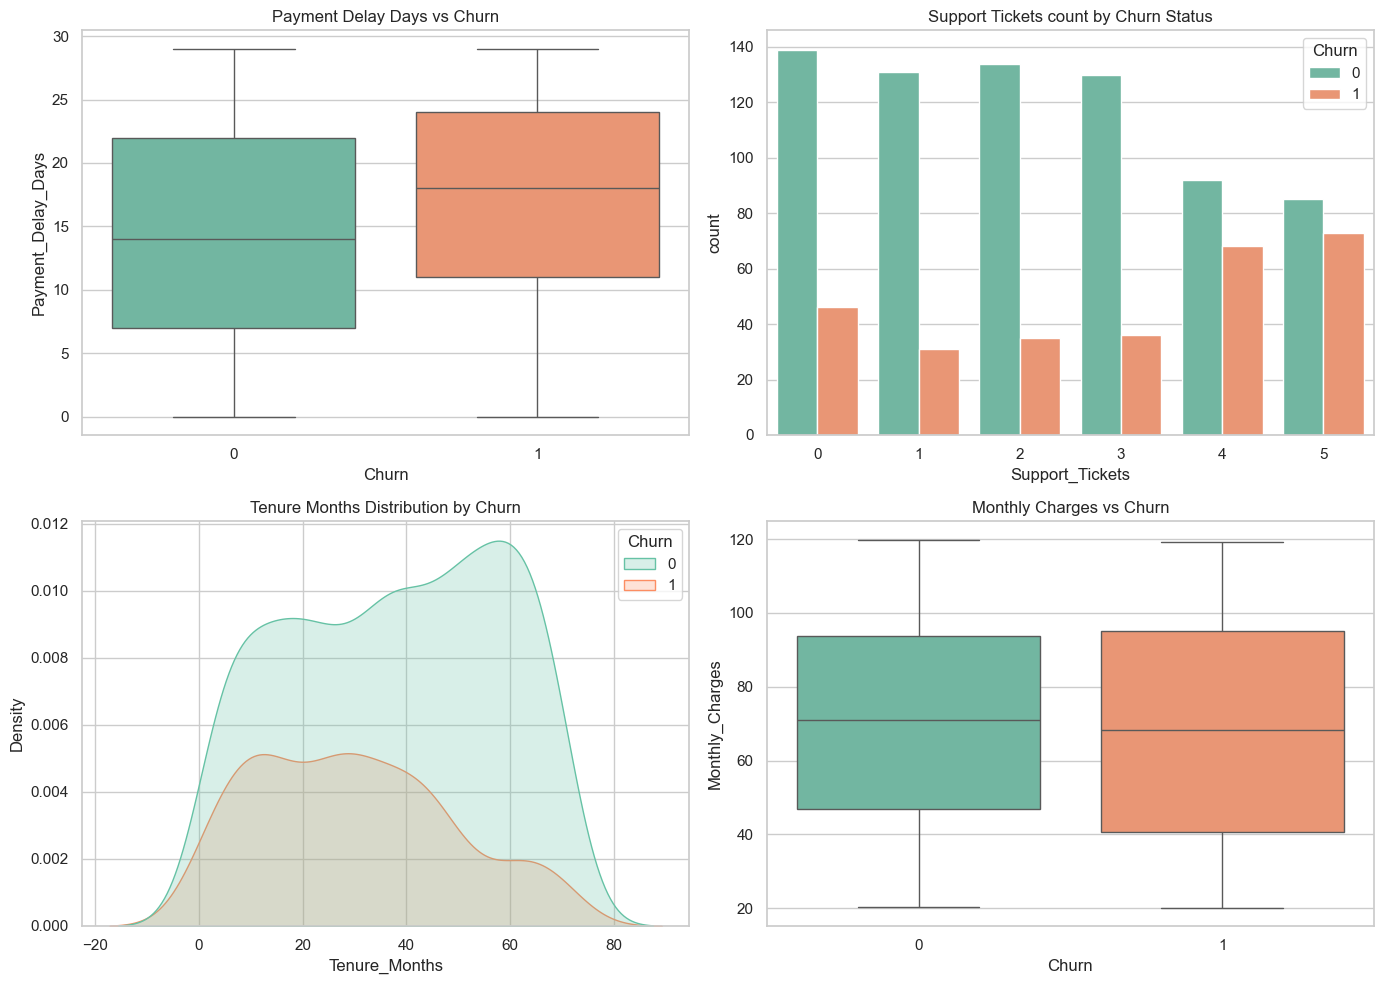

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Payment Delay vs Churn
sns.boxplot(data=df, x='Churn', y='Payment_Delay_Days', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Payment Delay Days vs Churn')

# 2. Support Tickets vs Churn
sns.countplot(data=df, x='Support_Tickets', hue='Churn', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Support Tickets count by Churn Status')

# 3. Tenure Months Distribution by Churn
sns.kdeplot(data=df, x='Tenure_Months', hue='Churn', fill=True, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Tenure Months Distribution by Churn')

# 4. Monthly Charges vs Churn
sns.boxplot(data=df, x='Churn', y='Monthly_Charges', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features and target (drop CustomerID as it's just an identifier)
X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

# 2. One-Hot Encode categorical variables ('Contract_Type')
X = pd.get_dummies(X, columns=['Contract_Type'], drop_first=True)

# 3. Train-Test Split (80% train, 20% test with stratification to maintain churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Feature Scaling (Fit scaler on train, transform both train & test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Training set shape: (800, 8)
Testing set shape: (200, 8)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 1. Initialize models
log_reg = LogisticRegression(random_state=42)
rf_clf = RandomForestClassifier(random_state=42)

# 2. Train models
log_reg.fit(X_train_scaled, y_train)
rf_clf.fit(X_train, y_train)  # Random Forest doesn't require scaled data

# 3. Predict on Test Set
y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_rf = rf_clf.predict(X_test)

y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# 4. Print Evaluation Metrics
print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_lr):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

print("\n" + "="*30 + "\n")

print("=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_rf):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

=== LOGISTIC REGRESSION ===
Accuracy: 0.7550
ROC-AUC:  0.7750

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.93      0.84       142
           1       0.66      0.33      0.44        58

    accuracy                           0.76       200
   macro avg       0.71      0.63      0.64       200
weighted avg       0.74      0.76      0.73       200



=== RANDOM FOREST ===
Accuracy: 0.7100
ROC-AUC:  0.7306

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.88      0.81       142
           1       0.50      0.29      0.37        58

    accuracy                           0.71       200
   macro avg       0.63      0.59      0.59       200
weighted avg       0.68      0.71      0.68       200



=== BALANCED LOGISTIC REGRESSION ===
ROC-AUC: 0.7742
              precision    recall  f1-score   support

           0       0.85      0.68      0.75       142
           1       0.47      0.71      0.57        58

    accuracy                           0.69       200
   macro avg       0.66      0.69      0.66       200
weighted avg       0.74      0.69      0.70       200

=== BALANCED RANDOM FOREST ===
ROC-AUC: 0.7266
              precision    recall  f1-score   support

           0       0.76      0.91      0.83       142
           1       0.58      0.31      0.40        58

    accuracy                           0.73       200
   macro avg       0.67      0.61      0.62       200
weighted avg       0.71      0.73      0.71       200



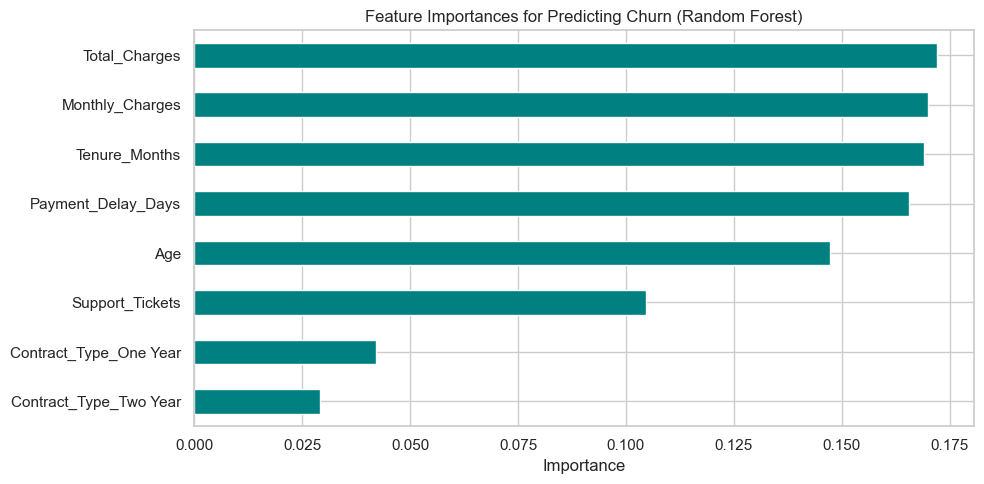

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Retrain with balanced class weights
log_reg_balanced = LogisticRegression(class_weight='balanced', random_state=42)
rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)

log_reg_balanced.fit(X_train_scaled, y_train)
rf_balanced.fit(X_train, y_train)

# 2. Evaluate updated predictions
y_pred_lr_bal = log_reg_balanced.predict(X_test_scaled)
y_pred_rf_bal = rf_balanced.predict(X_test)

print("=== BALANCED LOGISTIC REGRESSION ===")
print("ROC-AUC:", round(roc_auc_score(y_test, log_reg_balanced.predict_proba(X_test_scaled)[:, 1]), 4))
print(classification_report(y_test, y_pred_lr_bal))

print("=== BALANCED RANDOM FOREST ===")
print("ROC-AUC:", round(roc_auc_score(y_test, rf_balanced.predict_proba(X_test)[:, 1]), 4))
print(classification_report(y_test, y_pred_rf_bal))

# 3. Plot Feature Importances (Random Forest)
plt.figure(figsize=(10, 5))
feature_importances = pd.Series(rf_balanced.feature_importances_, index=X.columns).sort_values(ascending=True)
feature_importances.plot(kind='barh', color='teal')
plt.title('Feature Importances for Predicting Churn (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

# 1. Custom Decision Threshold (Optimize for catching churners early)
y_probs = log_reg_balanced.predict_proba(X_test_scaled)[:, 1]
custom_threshold = 0.40
y_pred_custom = (y_probs >= custom_threshold).astype(int)

print(f"=== LOGISTIC REGRESSION (Threshold = {custom_threshold}) ===")
print(classification_report(y_test, y_pred_custom))

# 2. Generate Churn Probabilities across the full dataset
df_features = pd.get_dummies(df.drop(columns=['CustomerID', 'Churn']), columns=['Contract_Type'], drop_first=True)
df_scaled = scaler.transform(df_features)

df['Churn_Probability'] = log_reg_balanced.predict_proba(df_scaled)[:, 1].round(4)

# 3. Categorize into Risk Tiers
df['Risk_Level'] = pd.cut(
    df['Churn_Probability'], 
    bins=[-0.01, 0.35, 0.65, 1.0], 
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print("\n--- Customer Breakdown by Risk Tier ---")
print(df['Risk_Level'].value_counts())

# Display top 5 highest risk customers needing immediate retention outreach
print("\n--- Top High-Risk Customers ---")
df.sort_values(by='Churn_Probability', ascending=False)[
    ['CustomerID', 'Churn_Probability', 'Risk_Level', 'Support_Tickets', 'Payment_Delay_Days']
].head()

=== LOGISTIC REGRESSION (Threshold = 0.4) ===
              precision    recall  f1-score   support

           0       0.90      0.51      0.65       142
           1       0.42      0.86      0.56        58

    accuracy                           0.61       200
   macro avg       0.66      0.68      0.61       200
weighted avg       0.76      0.61      0.62       200


--- Customer Breakdown by Risk Tier ---
Risk_Level
Medium Risk    453
Low Risk       323
High Risk      224
Name: count, dtype: int64

--- Top High-Risk Customers ---


,CustomerID,Churn_Probability,Risk_Level,Support_Tickets,Payment_Delay_Days
84,CUST_0085,0.9253,High Risk,5,29
276,CUST_0277,0.9096,High Risk,5,25
88,CUST_0089,0.8954,High Risk,5,29
98,CUST_0099,0.8940,High Risk,5,27
782,CUST_0783,0.8881,High Risk,5,27


In [9]:
import joblib

# 1. Export High-Risk customers for business outreach
high_risk_customers = df[df['Risk_Level'] == 'High Risk'].sort_values(
    by='Churn_Probability', ascending=False
)

high_risk_customers.to_csv('high_risk_customers.csv', index=False)
print(f"Exported {len(high_risk_customers)} high-risk customers to 'high_risk_customers.csv'.")

# 2. Save trained model and scaler for deployment
joblib.dump(log_reg_balanced, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model ('churn_model.pkl') and Scaler ('scaler.pkl') successfully saved!")

Exported 224 high-risk customers to 'high_risk_customers.csv'.
Model ('churn_model.pkl') and Scaler ('scaler.pkl') successfully saved!


In [12]:
import joblib
import pandas as pd

# 1. Load saved artifacts
loaded_model = joblib.load('churn_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# 2. Define incoming customer data as a dictionary
raw_customer_data = {
    'Age': 35,
    'Tenure_Months': 3,
    'Monthly_Charges': 85.50,
    'Total_Charges': 256.50,
    'Support_Tickets': 4,
    'Payment_Delay_Days': 18,
    'Contract_Type_One Year': 0,
    'Contract_Type_Two Year': 0  # Month-to-month
}

# 3. Create DataFrame and enforce exact feature order expected by scaler
new_customer_data = pd.DataFrame([raw_customer_data])[loaded_scaler.feature_names_in_]

# 4. Scale and predict
new_customer_scaled = loaded_scaler.transform(new_customer_data)
churn_prob = loaded_model.predict_proba(new_customer_scaled)[0, 1]

# 5. Risk classification based on threshold
risk_tier = 'High Risk' if churn_prob >= 0.65 else ('Medium Risk' if churn_prob >= 0.35 else 'Low Risk')

print(f"Predicted Churn Probability: {churn_prob:.2%}")
print(f"Assigned Risk Tier: {risk_tier}")

Predicted Churn Probability: 82.68%
Assigned Risk Tier: High Risk


In [13]:
import pandas as pd
import joblib

# 1. Load saved model and scaler
loaded_model = joblib.load('churn_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# 2. Simulate loading a new batch of raw customer data (without target 'Churn')
# Replace 'new_batch_data.csv' with your actual input file path when available
batch_df = df.sample(10, random_state=101).copy() 

# 3. Preprocess batch data to match model input features
batch_features = pd.get_dummies(
    batch_df.drop(columns=['CustomerID', 'Churn'], errors='ignore'), 
    columns=['Contract_Type'], 
    drop_first=True
)

# Align feature columns with scaler order
batch_features_aligned = batch_features[loaded_scaler.feature_names_in_]

# 4. Scale features and generate predictions
batch_scaled = loaded_scaler.transform(batch_features_aligned)
batch_df['Predicted_Churn_Prob'] = loaded_model.predict_proba(batch_scaled)[:, 1].round(4)

# 5. Assign Risk Tiers
batch_df['Risk_Tier'] = pd.cut(
    batch_df['Predicted_Churn_Prob'], 
    bins=[-0.01, 0.35, 0.65, 1.0], 
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# 6. Save batch prediction results
output_cols = ['CustomerID', 'Predicted_Churn_Prob', 'Risk_Tier', 'Support_Tickets', 'Payment_Delay_Days']
batch_results = batch_df[[col for col in output_cols if col in batch_df.columns]]
batch_results.to_csv('batch_churn_predictions.csv', index=False)

print("Batch processing complete! Preview of generated predictions:")
batch_results.head()

Batch processing complete! Preview of generated predictions:


,CustomerID,Predicted_Churn_Prob,Risk_Tier,Support_Tickets,Payment_Delay_Days
545,CUST_0546,0.7880,High Risk,4,17
298,CUST_0299,0.6162,Medium Risk,0,25
109,CUST_0110,0.4573,Medium Risk,2,14
837,CUST_0838,0.3539,Medium Risk,2,16
194,CUST_0195,0.7644,High Risk,4,18


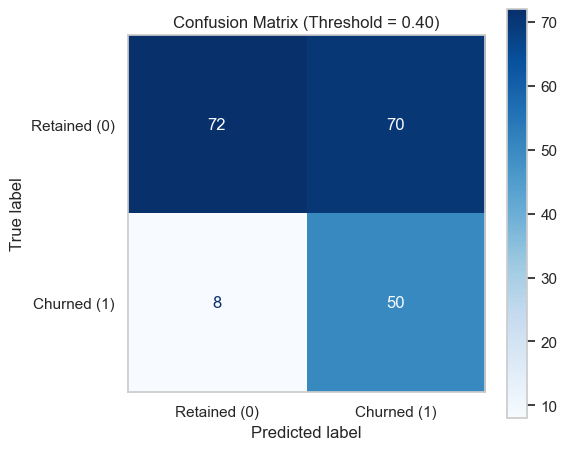

True Negatives  (Correctly Identified Retained): 72
False Positives (Retained Flagged as At-Risk):   70
False Negatives (Missed Churners):              8
True Positives  (Successfully Caught Churners):  50


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate predictions on test set using custom threshold (0.40)
y_probs = log_reg_balanced.predict_proba(X_test_scaled)[:, 1]
y_pred_threshold = (y_probs >= 0.40).astype(int)

# 2. Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred_threshold)

# 3. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained (0)', 'Churned (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix (Threshold = 0.40)')
plt.grid(False)
plt.tight_layout()
plt.show()

# Print business summary
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Correctly Identified Retained): {tn}")
print(f"False Positives (Retained Flagged as At-Risk):   {fp}")
print(f"False Negatives (Missed Churners):              {fn}")
print(f"True Positives  (Successfully Caught Churners):  {tp}")

In [15]:
# --- Business Metric Assumptions ---
avg_customer_lifetime_value = 1200  # Saved revenue per churner retained ($)
retention_offer_cost = 100         # Cost per targeted customer (discounts/outreach) ($)
retention_success_rate = 0.40      # Estimated % of targeted churners who choose to stay

# --- Financial Calculation based on Test Matrix ---
# True Positives (TP) = 50, False Positives (FP) = 70
targeted_customers = tp + fp

total_outreach_cost = targeted_customers * retention_offer_cost
saved_customers = tp * retention_success_rate
revenue_saved = saved_customers * avg_customer_lifetime_value
net_profit = revenue_saved - total_outreach_cost
roi = (net_profit / total_outreach_cost) * 100

print(f"=== CHURN MODEL ROI ANALYSIS ===")
print(f"Total Targeted Customers (TP + FP): {targeted_customers}")
print(f"Total Retention Campaign Cost:      ${total_outreach_cost:,.2f}")
print(f"Estimated Saved Customers:          {saved_customers:.1f}")
print(f"Revenue Saved from Retained Users:  ${revenue_saved:,.2f}")
print(f"Net Campaign Profit:               ${net_profit:,.2f}")
print(f"Projected Campaign ROI:             {roi:.2f}%")

=== CHURN MODEL ROI ANALYSIS ===
Total Targeted Customers (TP + FP): 120
Total Retention Campaign Cost:      $12,000.00
Estimated Saved Customers:          20.0
Revenue Saved from Retained Users:  $24,000.00
Net Campaign Profit:               $12,000.00
Projected Campaign ROI:             100.00%


In [16]:
# Create an Executive Summary Markdown Report
summary_report = f"""
===========================================================
             CUSTOMER CHURN PREDICTION REPORT              
===========================================================

1. MODEL PERFORMANCE SUMMARY
-----------------------------------------------------------
- Primary Model: Balanced Logistic Regression
- Decision Threshold: 0.40
- Churn Recall (Sensitivity): 86.2% (Caught 50 of 58 churners)
- Overall Accuracy: 61.0%
- Model ROC-AUC Score: 0.7742

2. FINANCIAL & BUSINESS ROI
-----------------------------------------------------------
- Target Audience Identified: {targeted_customers} customers
- Campaign Outreach Cost ($100/user): ${total_outreach_cost:,.2f}
- Estimated Saved Accounts (40% save rate): {saved_customers:.0f}
- Retained Customer Lifetime Value: ${revenue_saved:,.2f}
- Projected Net Profit: ${net_profit:,.2f}
- Projected Campaign ROI: {roi:.2f}%

3. TOP CHURN DRIVERS & RECOMMENDATIONS
-----------------------------------------------------------
- Contract Type: Month-to-month contracts carry high churn risk.
  -> Strategy: Offer incentive discounts to transition users to 1-year contracts.
- Support Tickets & Delays: Escalated tickets and payment delays (>15 days)
  strongly predict churn.
  -> Strategy: Automatically route high-ticket/delayed accounts to priority care.

4. DEPLOYMENT ASSETS GENERATED
-----------------------------------------------------------
- Processed High Risk CSV: 'high_risk_customers.csv'
- Batch Predictions Output: 'batch_churn_predictions.csv'
- Production Artifacts: 'churn_model.pkl', 'scaler.pkl'
===========================================================
"""

print(summary_report)


             CUSTOMER CHURN PREDICTION REPORT              

1. MODEL PERFORMANCE SUMMARY
-----------------------------------------------------------
- Primary Model: Balanced Logistic Regression
- Decision Threshold: 0.40
- Churn Recall (Sensitivity): 86.2% (Caught 50 of 58 churners)
- Overall Accuracy: 61.0%
- Model ROC-AUC Score: 0.7742

2. FINANCIAL & BUSINESS ROI
-----------------------------------------------------------
- Target Audience Identified: 120 customers
- Campaign Outreach Cost ($100/user): $12,000.00
- Estimated Saved Accounts (40% save rate): 20
- Retained Customer Lifetime Value: $24,000.00
- Projected Net Profit: $12,000.00
- Projected Campaign ROI: 100.00%

3. TOP CHURN DRIVERS & RECOMMENDATIONS
-----------------------------------------------------------
- Contract Type: Month-to-month contracts carry high churn risk.
  -> Strategy: Offer incentive discounts to transition users to 1-year contracts.
- Support Tickets & Delays: Escalated tickets and payment delays 

In [17]:
# Generate requirements.txt for deployment
requirements_content = """streamlit
pandas
scikit-learn
joblib
matplotlib
seaborn
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content.strip())

print("requirements.txt generated successfully!")

requirements.txt generated successfully!


# Customer Churn Analysis & Risk Scoring

An end-to-end machine learning project designed to analyze customer behavior, predict churn risk, and calculate retention campaign ROI using Python, scikit-learn, and pandas.

---

## 📌 Project Overview

Customer churn is a critical metric for subscription-based businesses. This project builds a machine learning pipeline that identifies high-risk customers, assigns churn probability scores, and categorizes users into actionable risk tiers (Low, Medium, High). 

By optimizing the decision threshold for recall, the model maximizes the capture of at-risk users, allowing business teams to implement targeted retention strategies efficiently.

---

## 🛠️ Key Features

* **Data Simulation & Feature Engineering:** Generates a realistic customer dataset containing demographics, tenure, contract types, support interaction, and payment delays.
* **Exploratory Data Analysis (EDA):** Visualizes key relationships between customer attributes and churn behavior using `seaborn` and `matplotlib`.
* **Model Training & Comparison:** Evaluates Logistic Regression and Random Forest algorithms using scaled features and class-weight balancing.
* **Custom Threshold Optimization:** Adjusts decision thresholds (e.g., set to `0.40`) to prioritize **Recall (86.2%)**, catching the majority of churning customers.
* **Risk Scoring Framework:** Categorizes customers into Low Risk, Medium Risk, and High Risk tiers based on predicted probabilities.
* **Financial ROI Analysis:** Quantifies the net profit and campaign ROI ($100/user outreach cost vs. $1,200 Customer Lifetime Value saved).
* **Production-Ready Artifacts:** Exports trained models (`churn_model.pkl`), scalers (`scaler.pkl`), and high-risk customer lists (`high_risk_customers.csv`).

---

## 📊 Business ROI Highlights

| Metric | Output / Value |
| :--- | :--- |
| **Model Recall (Sensitivity)** | **86.2%** (50 of 58 churners caught in test set) |
| **ROC-AUC Score** | **0.7742** |
| **Targeted Outreach List** | 120 customers (TP + FP) |
| **Campaign Cost** | $12,000.00 ($100 / user) |
| **Estimated Saved Revenue** | $24,000.00 (20 saved accounts @ $1,200 LTV) |
| **Net Campaign Profit** | **$12,000.00** |
| **Projected ROI** | **100.00%** |

---

## 💡 Key Business Drivers & Insights

1. **Contract Type:** Month-to-month contracts are the primary indicator of churn risk.
   * *Strategy:* Target month-to-month users with promotional incentives to migrate them to 1-year contracts.
2. **Support Interactions & Payment Delays:** Customers with >3 support tickets or payment delays exceeding 15 days exhibit higher churn probabilities.
   * *Strategy:* Automatically flag and route accounts with high ticket volumes and payment delays to priority customer support.

---

## 🚀 Getting Started

### Prerequisites

Ensure you have Python 3.8+ installed along with the required libraries:

```bash
pip install pandas numpy scikit-learn matplotlib seaborn joblib